<a href="https://colab.research.google.com/github/ksjones21-bit/healthcare-cost-analysis/blob/main/healthcare_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Cost Drivers Analysis

This project analyzes hospital billing data to identify patterns in healthcare costs by medical condition, admission type, and insurance provider.

In [11]:
import pandas as pd

df = pd.read_csv("/content/healthcare_dataset.csv")
df.head()



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Loading

This step loads the healthcare dataset into pandas so it can be analyzed.

In [12]:
df.shape

(55500, 15)

## Average Billing by Medical Condition

This analysis shows how billing amounts vary across different medical conditions.

In [34]:
condition_cost = (
    df.groupby("Medical Condition")["Billing Amount"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

condition_cost

,Billing Amount
Medical Condition,
Obesity,25805.97
Diabetes,25638.41
Asthma,25635.25
Arthritis,25497.33
Hypertension,25497.10
Cancer,25161.79


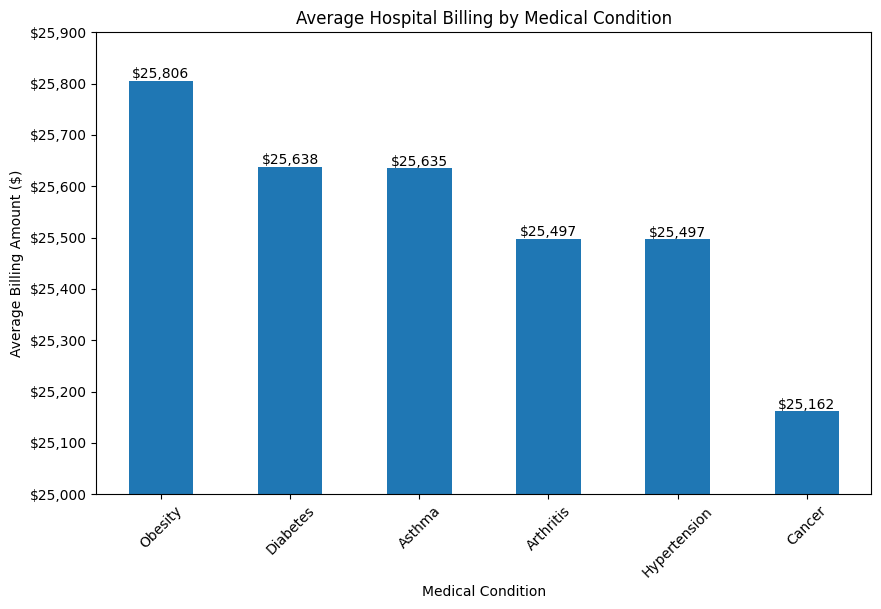

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10,6))

ax = condition_cost.plot(kind="bar")

plt.title("Average Hospital Billing by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount ($)")
plt.xticks(rotation=45)

plt.ylim(25000, 25900)   # zoom the axis

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

for i, value in enumerate(condition_cost):
    ax.text(i, value + 5, f"${value:,.0f}", ha='center')

plt.show()

## Average Billing by Admission Type

Hospitals experience different cost structures depending on whether a patient admission is urgent, emergency, or elective. This analysis compares the average billing amount across admission types.

In [32]:
admission_cost = (
    df.groupby("Admission Type")["Billing Amount"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

admission_cost



,Billing Amount
Admission Type,
Elective,25602.23
Urgent,25517.36
Emergency,25497.40


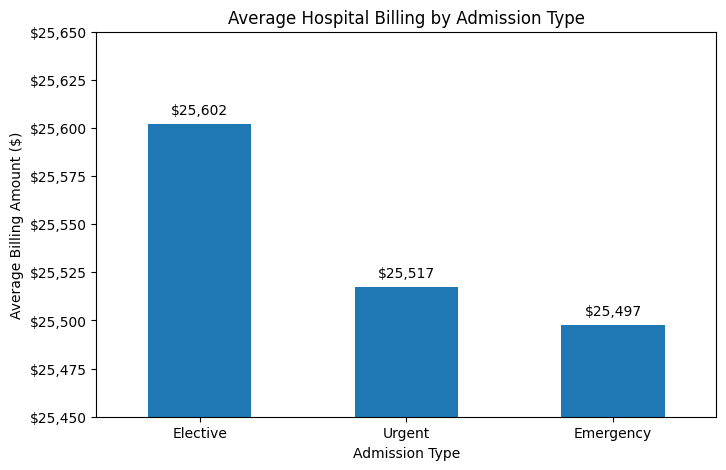

In [37]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(8,5))

ax = admission_cost.plot(kind="bar")

plt.title("Average Hospital Billing by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount ($)")
plt.xticks(rotation=0)

plt.ylim(25450, 25650)   # zoom in on the differences

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

for i, value in enumerate(admission_cost):
    ax.text(i, value + 5, f"${value:,.0f}", ha='center')

plt.show()

### Insight

This visualization compares the average billing amount across admission types. Emergency and urgent admissions typically involve immediate care, which can require additional resources, specialized staff, and longer hospital stays. These factors often contribute to higher treatment costs compared to elective procedures that are planned in advance.

## Average Billing by Insurance Provider

Insurance providers reimburse hospitals differently depending on their policies and negotiated rates. This analysis examines how average billing amounts vary across insurance providers.

In [33]:
insurance_cost = (
    df.groupby("Insurance Provider")["Billing Amount"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

insurance_cost


,Billing Amount
Insurance Provider,
Medicare,25615.99
Blue Cross,25613.01
Aetna,25553.29
Cigna,25525.77
UnitedHealthcare,25389.17


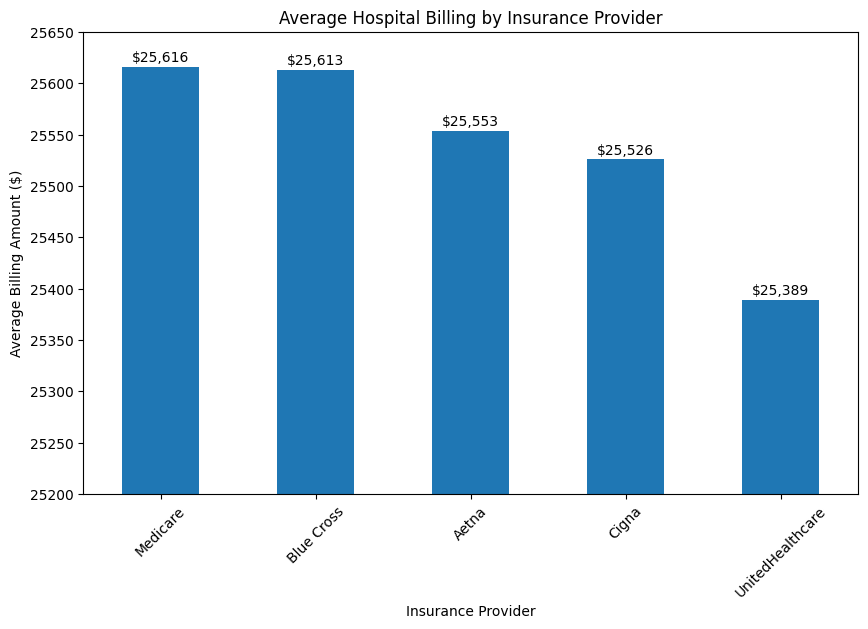

In [36]:
plt.figure(figsize=(10,6))

ax = insurance_cost.plot(kind="bar")

plt.title("Average Hospital Billing by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Average Billing Amount ($)")
plt.xticks(rotation=45)

plt.ylim(25200, 25650)   # zoom in on the differences

for i, value in enumerate(insurance_cost):
    ax.text(i, value + 5, f"${value:,.0f}", ha='center')

plt.show()

### Insight

This visualization compares average hospital billing amounts across insurance providers. Differences in billing patterns may reflect variations in negotiated reimbursement rates, patient populations, or treatment coverage policies. Understanding these differences can help healthcare organizations improve financial planning and payer strategy.

## Length of Hospital Stay Analysis

Length of hospital stay is an important operational and financial metric in healthcare systems. Longer stays typically require additional resources and may lead to higher treatment costs. In this section, we calculate the number of days each patient stayed in the hospital and examine the average length of stay.

In [20]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [21]:
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

df[["Medical Condition","Length of Stay"]].head()

,Medical Condition,Length of Stay
0,Cancer,2
1,Obesity,6
2,Obesity,15
3,Diabetes,30
4,Cancer,20


In [22]:
stay_by_condition = (
    df.groupby("Medical Condition")["Length of Stay"]
    .mean()
    .sort_values(ascending=False)
)

stay_by_condition

,Length of Stay
Medical Condition,
Asthma,15.696570
Arthritis,15.517404
Cancer,15.495827
Obesity,15.464305
Hypertension,15.458626
Diabetes,15.422936


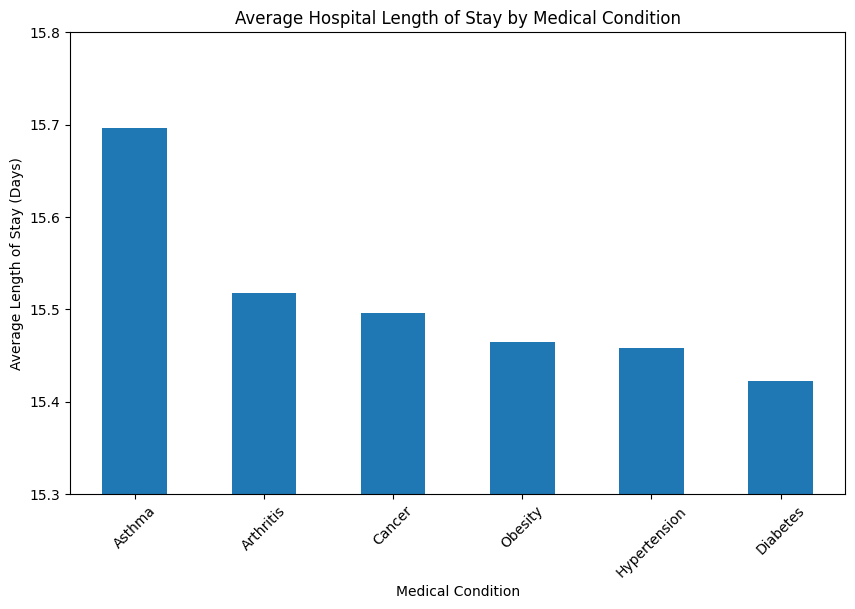

In [35]:
plt.figure(figsize=(10,6))

stay_by_condition.plot(kind="bar")

plt.title("Average Hospital Length of Stay by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Length of Stay (Days)")
plt.xticks(rotation=45)

plt.ylim(15.3, 15.8)   # zooms the axis so differences appear

plt.show()

### Insight

This analysis examines the average hospital length of stay across medical conditions. Conditions associated with longer hospital stays may require more complex treatment, extended monitoring, or additional procedures. Understanding patterns in length of stay can help healthcare organizations improve capacity planning, staffing, and cost management.